# Required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier




# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Dataset/Dataset - Updated.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (1205, 12)


,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


# EDA

In [ ]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Dataset structure
df.info()

# Statistical summary
df.describe()


Dataset Shape: (1205, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   object 
dtypes: float64(7), int64(4), object(1)
memory usage: 113.1+ KB


,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
count,1205.000000,1200.000000,1201.000000,1203.000000,1205.000000,1187.000000,1203.000000,1203.000000,1205.000000,1205.00000,1203.000000
mean,27.482988,116.819167,77.166528,7.501064,98.395851,23.315080,0.175395,0.288446,0.117842,0.33444,75.817124
std,9.196765,18.715502,14.305148,3.049522,1.088363,3.875682,0.380463,0.453228,0.322555,0.47199,7.227338
min,10.000000,70.000000,40.000000,3.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.00000,58.000000
25%,21.000000,100.000000,65.000000,6.000000,98.000000,20.450000,0.000000,0.000000,0.000000,0.00000,70.000000
50%,25.000000,120.000000,80.000000,6.900000,98.000000,23.000000,0.000000,0.000000,0.000000,0.00000,76.000000
75%,31.000000,130.000000,90.000000,7.900000,98.000000,25.000000,0.000000,1.000000,0.000000,1.00000,80.000000
max,65.000000,200.000000,140.000000,19.000000,103.000000,37.000000,1.000000,1.000000,1.000000,1.00000,92.000000


In [ ]:
df.isnull().sum()


,0
Age,0
Systolic BP,5
Diastolic,4
BS,2
Body Temp,0
BMI,18
Previous Complications,2
Preexisting Diabetes,2
Gestational Diabetes,0
Mental Health,0


In [ ]:
df = df.dropna()
df.isnull().sum()


,0
Age,0
Systolic BP,0
Diastolic,0
BS,0
Body Temp,0
BMI,0
Previous Complications,0
Preexisting Diabetes,0
Gestational Diabetes,0
Mental Health,0


/tmp/ipython-input-2827084064.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[TARGET_COL], palette="Set2")


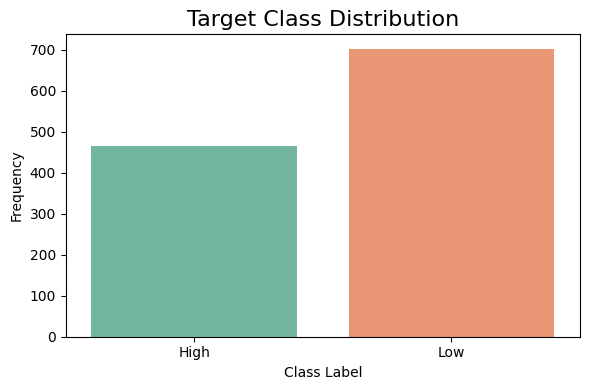

In [ ]:
TARGET_COL = "Risk Level"  # change if needed

plt.figure(figsize=(6, 4))
sns.countplot(x=df[TARGET_COL], palette="Set2")
plt.title("Target Class Distribution", fontsize=16)
plt.xlabel("Class Label")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


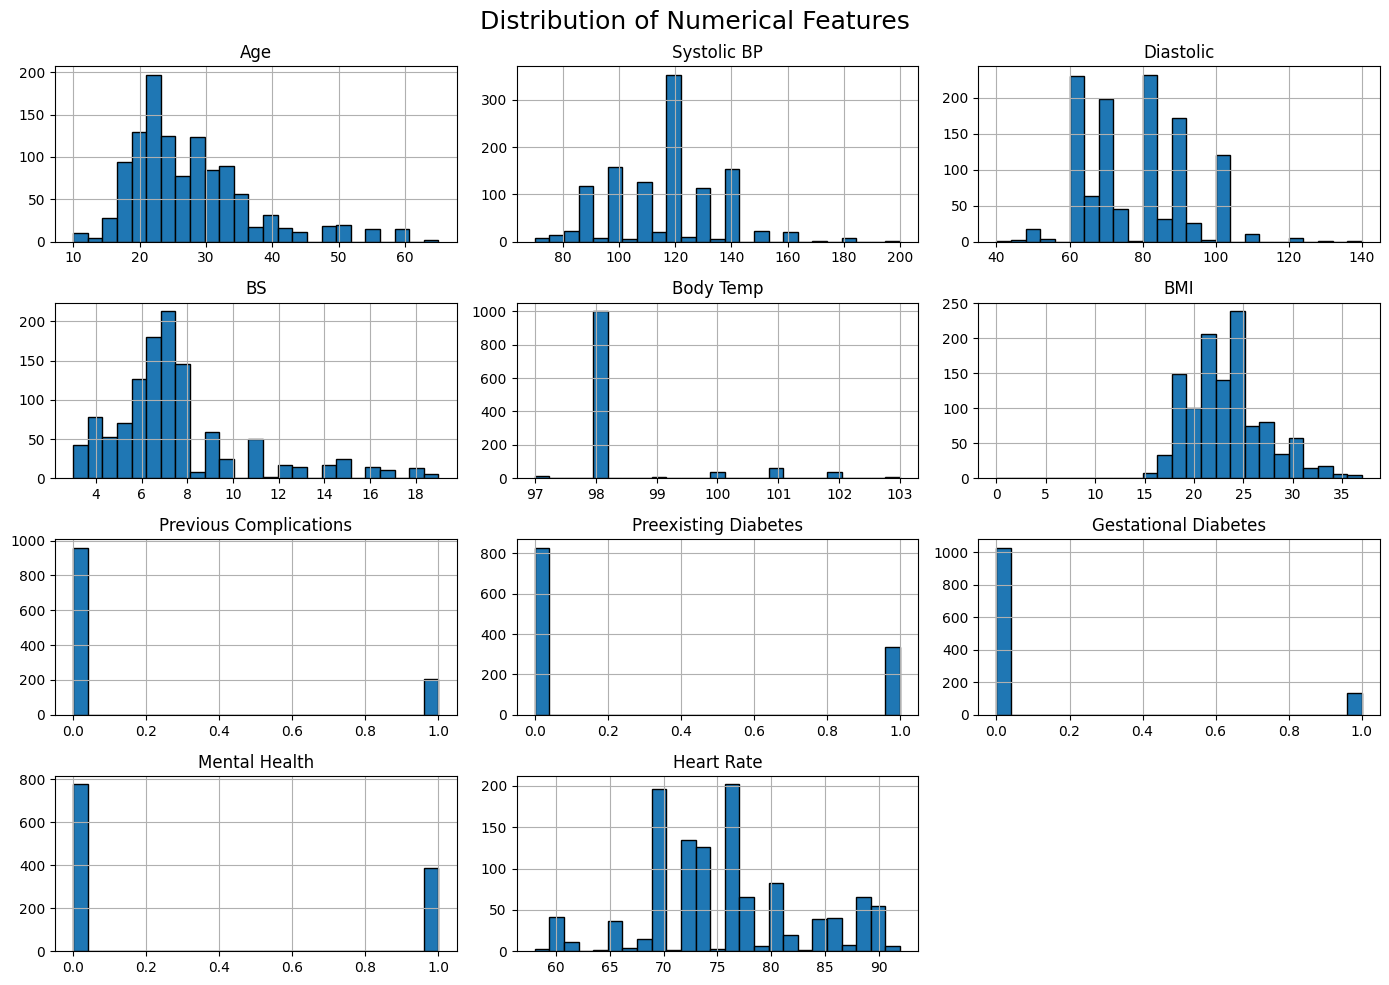

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(
    figsize=(14, 10),
    bins=25,
    edgecolor="black"
)
plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()



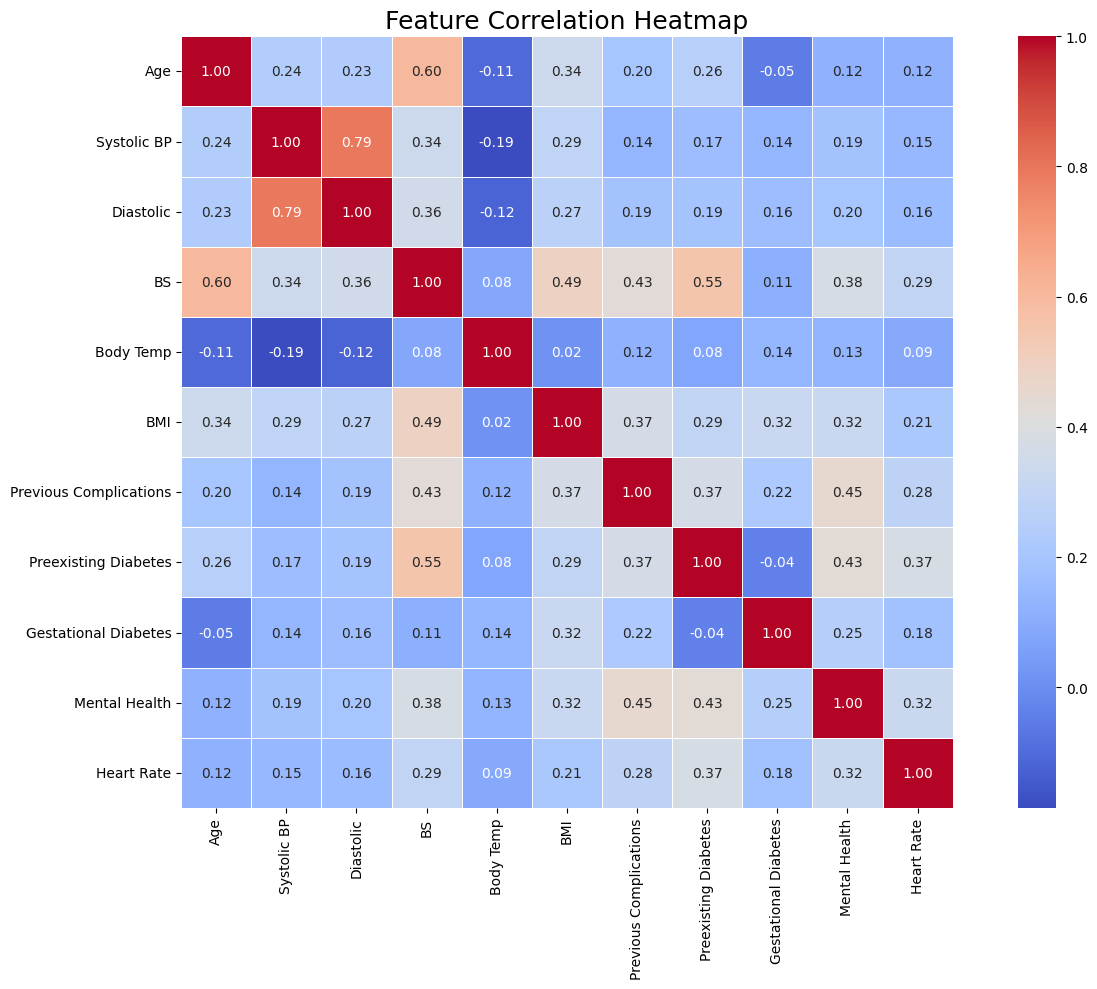

In [ ]:
plt.figure(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=18)
plt.tight_layout()
plt.show()


# Data Preprocessing

In [ ]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Encode target
if y.dtype == "object":
    y = LabelEncoder().fit_transform(y)

# Encode categorical features
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

# Standardization
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


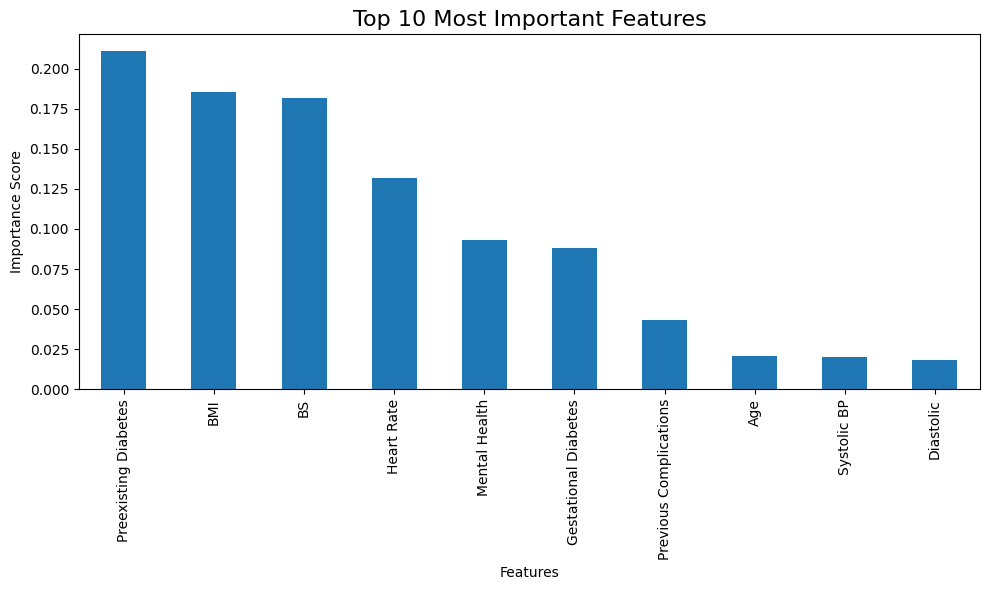

In [ ]:
rf_temp = RandomForestClassifier(n_estimators=200, random_state=42)
rf_temp.fit(X, y)

feature_importance = pd.Series(
    rf_temp.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind="bar")
plt.title("Top 10 Most Important Features", fontsize=16)
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.tight_layout()
plt.show()


# Data Split 80:20


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 932
Testing samples: 234


# RF

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        93
           1       0.98      1.00      0.99       141

    accuracy                           0.99       234
   macro avg       0.99      0.98      0.99       234
weighted avg       0.99      0.99      0.99       234



In [ ]:
from sklearn.metrics import accuracy_score

# Test Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 98.72%


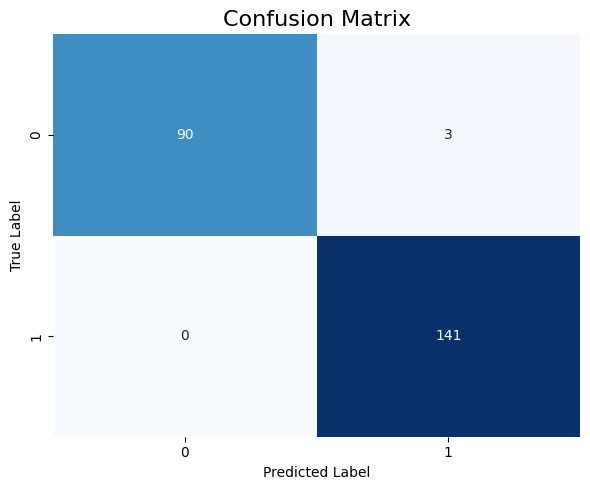

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix", fontsize=16)
plt.tight_layout()
plt.show()



========== RANDOM FOREST K-FOLD CV START ==========


================ FOLD 1 ================

Fold 1 Accuracy: 97.86%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97        93
           1       0.98      0.99      0.98       141

    accuracy                           0.98       234
   macro avg       0.98      0.98      0.98       234
weighted avg       0.98      0.98      0.98       234


================ FOLD 2 ================

Fold 2 Accuracy: 98.28%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        93
           1       0.99      0.98      0.99       140

    accuracy                           0.98       233
   macro avg       0.98      0.98      0.98       233
weighted avg       0.98      0.98      0.98       233


================ FOLD 3 ================

Fold 3 Accuracy: 99.14%

Classification Report:
              preci

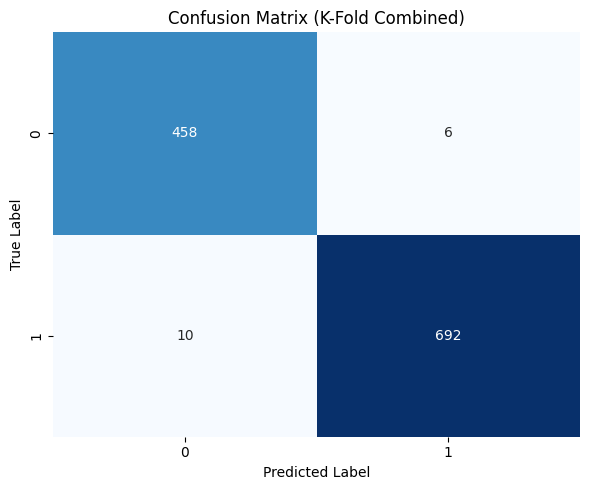


ROC AUC Score: 0.9992


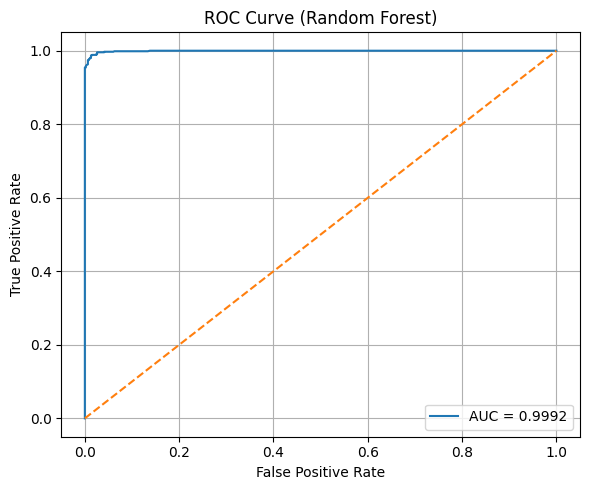


========== K-FOLD CV COMPLETED ==========



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ==============================
# K-Fold Cross Validation
# ==============================

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []
all_y_true = []
all_y_pred = []
all_y_prob = []

print("\n========== RANDOM FOREST K-FOLD CV START ==========\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\n================ FOLD {fold} ================")

    # Fix: Use .iloc for integer-location based indexing on DataFrame X
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

    print(f"\nFold {fold} Accuracy: {acc * 100:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# ==============================
# Overall Results
# ==============================

print("\n========== OVERALL RESULTS (ALL FOLDS) ==========\n")

print("Fold-wise Accuracy:")
for i, acc in enumerate(fold_accuracies, start=1):
    print(f"Fold {i}: {acc * 100:.2f}%")

print(f"\nMean Accuracy: {np.mean(fold_accuracies) * 100:.2f}%")
print(f"Std Deviation: {np.std(fold_accuracies) * 100:.2f}%")

print("\nOverall Classification Report:")
print(classification_report(all_y_true, all_y_pred))

# ==============================
# Confusion Matrix
# ==============================

cm = confusion_matrix(all_y_true, all_y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (K-Fold Combined)")
plt.tight_layout()
plt.show()

# ==============================
# ROC Curve (Binary only)
# ==============================

if len(np.unique(y)) == 2:
    y_prob = np.array(all_y_prob)[:, 1]

    fpr, tpr, _ = roc_curve(all_y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    print(f"\nROC AUC Score: {roc_auc:.4f}")

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Random Forest)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\n========== K-FOLD CV COMPLETED ==========\n")

# SVM


========== SVM K-FOLD CV START ==========


================ FOLD 1 ================

Fold 1 Accuracy: 97.44%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        93
           1       0.98      0.98      0.98       141

    accuracy                           0.97       234
   macro avg       0.97      0.97      0.97       234
weighted avg       0.97      0.97      0.97       234


================ FOLD 2 ================

Fold 2 Accuracy: 96.57%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        93
           1       0.99      0.96      0.97       140

    accuracy                           0.97       233
   macro avg       0.96      0.97      0.96       233
weighted avg       0.97      0.97      0.97       233


================ FOLD 3 ================

Fold 3 Accuracy: 97.42%

Classification Report:
              precision    re

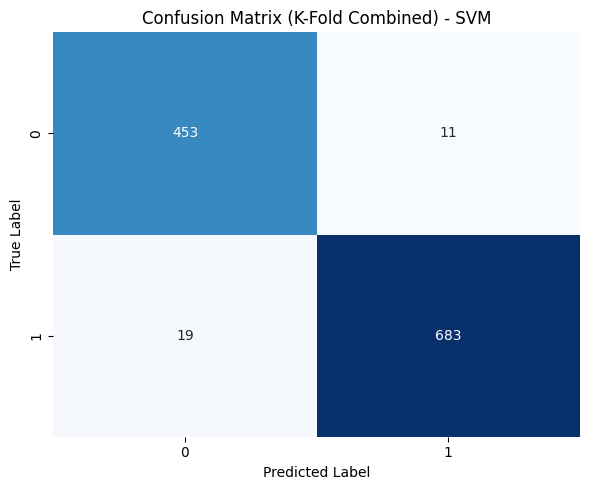


ROC AUC Score: 0.9967


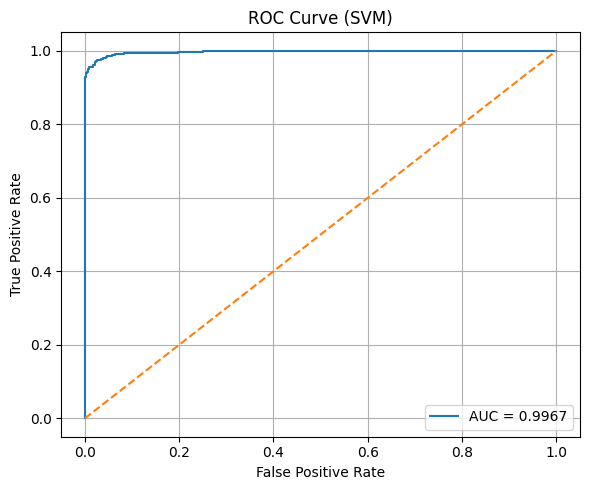


========== K-FOLD CV COMPLETED ==========



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ==============================
# K-Fold Cross Validation (SVM)
# ==============================

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []
all_y_true = []
all_y_pred = []
all_y_prob = []  # will store probabilities (binary) or decision scores (multi)

print("\n========== SVM K-FOLD CV START ==========\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\n================ FOLD {fold} ================")

    # Use .iloc for DataFrame X indexing
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Pipeline: Scaling + SVM
    # probability=True enables predict_proba (needed for ROC like your RF code)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # For binary, predict_proba works; for multi it returns (n_samples, n_classes)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

    print(f"\nFold {fold} Accuracy: {acc * 100:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# ==============================
# Overall Results
# ==============================

print("\n========== OVERALL RESULTS (ALL FOLDS) ==========\n")

print("Fold-wise Accuracy:")
for i, acc in enumerate(fold_accuracies, start=1):
    print(f"Fold {i}: {acc * 100:.2f}%")

print(f"\nMean Accuracy: {np.mean(fold_accuracies) * 100:.2f}%")
print(f"Std Deviation: {np.std(fold_accuracies) * 100:.2f}%")

print("\nOverall Classification Report:")
print(classification_report(all_y_true, all_y_pred))

# ==============================
# Confusion Matrix
# ==============================

cm = confusion_matrix(all_y_true, all_y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (K-Fold Combined) - SVM")
plt.tight_layout()
plt.show()

# ==============================
# ROC Curve (Binary only)
# ==============================

if len(np.unique(y)) == 2:
    y_prob_bin = np.array(all_y_prob)[:, 1]

    fpr, tpr, _ = roc_curve(all_y_true, y_prob_bin)
    roc_auc = auc(fpr, tpr)

    print(f"\nROC AUC Score: {roc_auc:.4f}")

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (SVM)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\n========== K-FOLD CV COMPLETED ==========\n")


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
model = SVC(
    kernel="rbf",     # common best default
    C=1.0,
    gamma="scale",
    random_state=42   # works in recent sklearn; if error, remove this line
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        93
           1       0.98      0.98      0.98       141

    accuracy                           0.97       234
   macro avg       0.97      0.97      0.97       234
weighted avg       0.97      0.97      0.97       234



In [ ]:
from sklearn.metrics import accuracy_score

# Test Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 97.44%


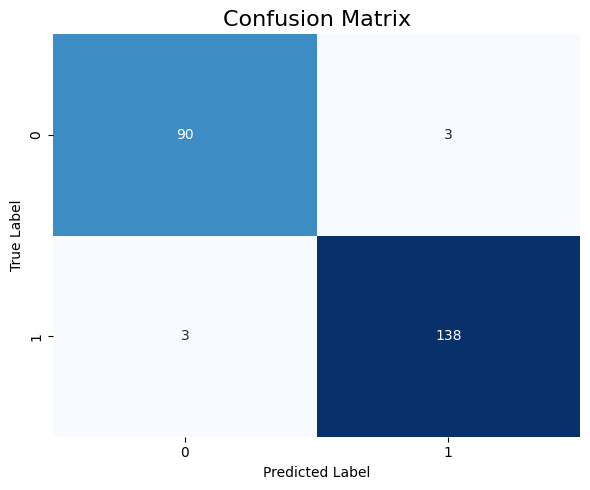

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix", fontsize=16)
plt.tight_layout()
plt.show()

# KNN


========== KNN K-FOLD CV START ==========


================ FOLD 1 ================

Fold 1 Accuracy: 95.73%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.95        93
           1       0.95      0.98      0.97       141

    accuracy                           0.96       234
   macro avg       0.96      0.95      0.96       234
weighted avg       0.96      0.96      0.96       234


================ FOLD 2 ================

Fold 2 Accuracy: 96.14%

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        93
           1       0.99      0.95      0.97       140

    accuracy                           0.96       233
   macro avg       0.96      0.96      0.96       233
weighted avg       0.96      0.96      0.96       233


================ FOLD 3 ================

Fold 3 Accuracy: 98.28%

Classification Report:
              precision    re

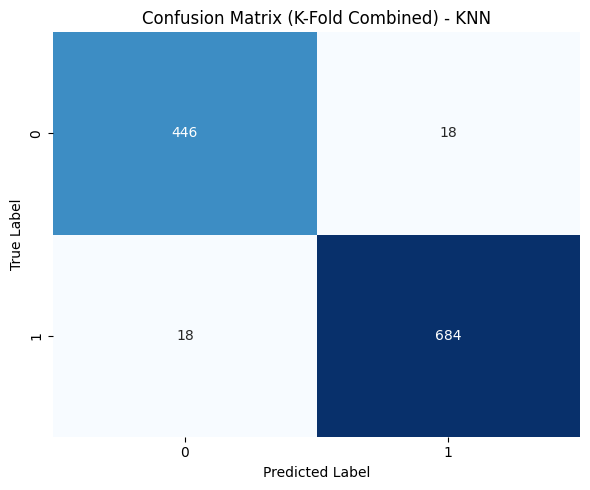


ROC AUC Score: 0.9890


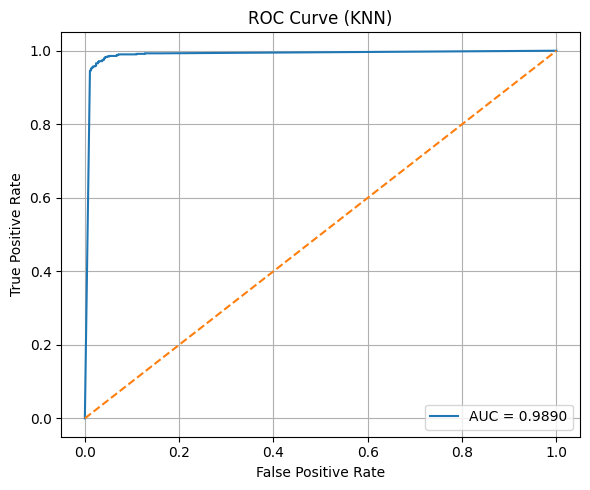


========== K-FOLD CV COMPLETED ==========



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ==============================
# K-Fold Cross Validation (KNN)
# ==============================

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []
all_y_true = []
all_y_pred = []
all_y_prob = []

print("\n========== KNN K-FOLD CV START ==========\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\n================ FOLD {fold} ================")

    # Use .iloc for DataFrame X indexing
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Pipeline: Scaling + KNN
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(
            n_neighbors=5,
            weights="distance",   # or "uniform"
            metric="minkowski",   # default (p=2 => euclidean)
            p=2
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

    print(f"\nFold {fold} Accuracy: {acc * 100:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# ==============================
# Overall Results
# ==============================

print("\n========== OVERALL RESULTS (ALL FOLDS) ==========\n")

print("Fold-wise Accuracy:")
for i, acc in enumerate(fold_accuracies, start=1):
    print(f"Fold {i}: {acc * 100:.2f}%")

print(f"\nMean Accuracy: {np.mean(fold_accuracies) * 100:.2f}%")
print(f"Std Deviation: {np.std(fold_accuracies) * 100:.2f}%")

print("\nOverall Classification Report:")
print(classification_report(all_y_true, all_y_pred))

# ==============================
# Confusion Matrix
# ==============================

cm = confusion_matrix(all_y_true, all_y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (K-Fold Combined) - KNN")
plt.tight_layout()
plt.show()

# ==============================
# ROC Curve (Binary only)
# ==============================

if len(np.unique(y)) == 2:
    y_prob_bin = np.array(all_y_prob)[:, 1]

    fpr, tpr, _ = roc_curve(all_y_true, y_prob_bin)
    roc_auc = auc(fpr, tpr)

    print(f"\nROC AUC Score: {roc_auc:.4f}")

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (KNN)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\n========== K-FOLD CV COMPLETED ==========\n")


Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        93
           1       0.99      0.97      0.98       141

    accuracy                           0.98       234
   macro avg       0.98      0.98      0.98       234
weighted avg       0.98      0.98      0.98       234



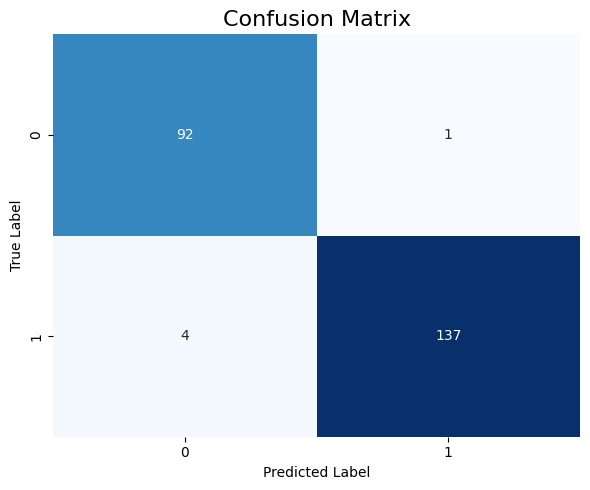

In [ ]:


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


model = KNeighborsClassifier(
    n_neighbors=5,        # commonly used value
    metric="minkowski",   # default distance
    p=2                   # Euclidean distance
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

# Test Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 97.86%


# XGB


========== XGBOOST K-FOLD CV START ==========


================ FOLD 1 ================

Fold 1 Accuracy: 97.86%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97        93
           1       0.99      0.98      0.98       141

    accuracy                           0.98       234
   macro avg       0.98      0.98      0.98       234
weighted avg       0.98      0.98      0.98       234


================ FOLD 2 ================

Fold 2 Accuracy: 99.57%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        93
           1       1.00      0.99      1.00       140

    accuracy                           1.00       233
   macro avg       0.99      1.00      1.00       233
weighted avg       1.00      1.00      1.00       233


================ FOLD 3 ================

Fold 3 Accuracy: 99.14%

Classification Report:
              precision  

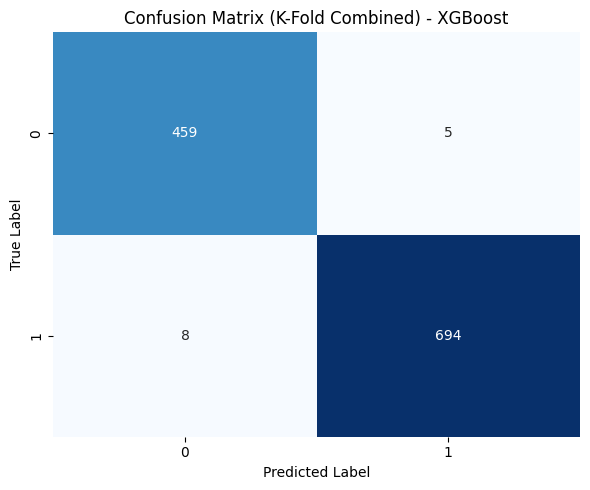


ROC AUC Score: 0.9993


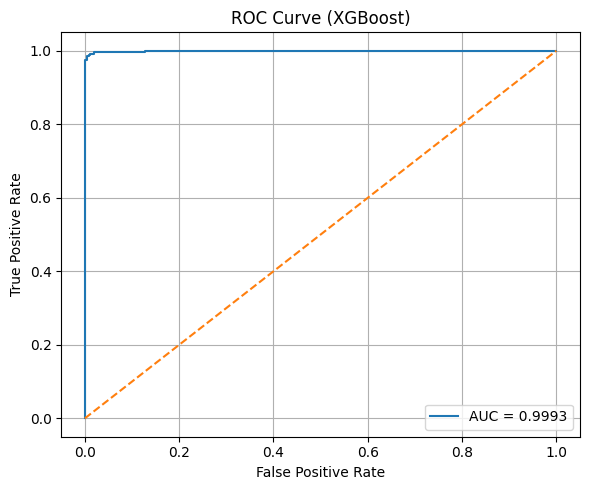


========== K-FOLD CV COMPLETED ==========



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ==============================
# K-Fold Cross Validation (XGBoost)
# ==============================

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []
all_y_true = []
all_y_pred = []
all_y_prob = []

print("\n========== XGBOOST K-FOLD CV START ==========\n")

# Number of classes (binary or multi-class)
n_classes = len(np.unique(y))

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\n================ FOLD {fold} ================")

    # Use .iloc for DataFrame X indexing
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # If your y labels are strings, uncomment below:
    # from sklearn.preprocessing import LabelEncoder
    # le = LabelEncoder()
    # y_train = le.fit_transform(y_train)
    # y_test = le.transform(y_test)

    # XGBoost model setup
    if n_classes == 2:
        model = XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    else:
        model = XGBClassifier(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="multi:softprob",
            num_class=n_classes,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

    print(f"\nFold {fold} Accuracy: {acc * 100:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# ==============================
# Overall Results
# ==============================

print("\n========== OVERALL RESULTS (ALL FOLDS) ==========\n")

print("Fold-wise Accuracy:")
for i, acc in enumerate(fold_accuracies, start=1):
    print(f"Fold {i}: {acc * 100:.2f}%")

print(f"\nMean Accuracy: {np.mean(fold_accuracies) * 100:.2f}%")
print(f"Std Deviation: {np.std(fold_accuracies) * 100:.2f}%")

print("\nOverall Classification Report:")
print(classification_report(all_y_true, all_y_pred))

# ==============================
# Confusion Matrix
# ==============================

cm = confusion_matrix(all_y_true, all_y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (K-Fold Combined) - XGBoost")
plt.tight_layout()
plt.show()

# ==============================
# ROC Curve (Binary only)
# ==============================

if n_classes == 2:
    y_prob_bin = np.array(all_y_prob)[:, 1]

    fpr, tpr, _ = roc_curve(all_y_true, y_prob_bin)
    roc_auc = auc(fpr, tpr)

    print(f"\nROC AUC Score: {roc_auc:.4f}")

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (XGBoost)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\n========== K-FOLD CV COMPLETED ==========\n")


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        93
           1       0.99      1.00      0.99       141

    accuracy                           0.99       234
   macro avg       0.99      0.99      0.99       234
weighted avg       0.99      0.99      0.99       234



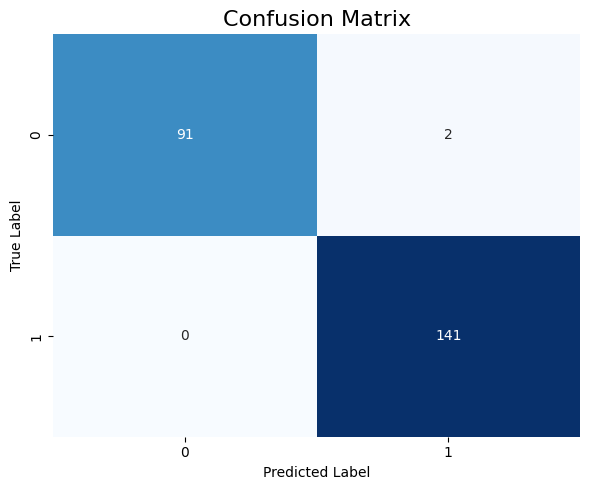

In [ ]:


from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


model = XGBClassifier(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

# Test Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 97.86%


# DT


========== DECISION TREE K-FOLD CV START ==========


================ FOLD 1 ================

Fold 1 Accuracy: 97.86%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97        93
           1       0.99      0.98      0.98       141

    accuracy                           0.98       234
   macro avg       0.98      0.98      0.98       234
weighted avg       0.98      0.98      0.98       234


================ FOLD 2 ================

Fold 2 Accuracy: 98.71%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98        93
           1       0.99      0.99      0.99       140

    accuracy                           0.99       233
   macro avg       0.99      0.99      0.99       233
weighted avg       0.99      0.99      0.99       233


================ FOLD 3 ================

Fold 3 Accuracy: 96.57%

Classification Report:
              preci

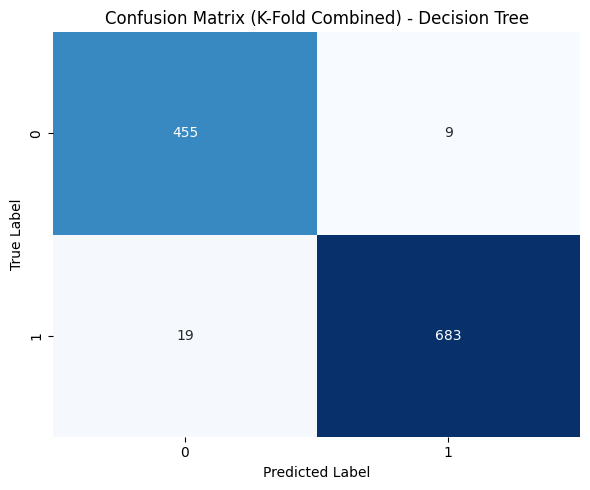


ROC AUC Score: 0.9768


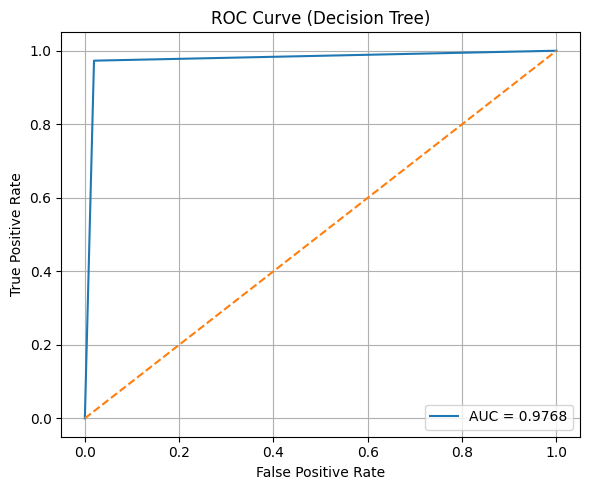


========== K-FOLD CV COMPLETED ==========



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ==============================
# K-Fold Cross Validation (Decision Tree)
# ==============================

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []
all_y_true = []
all_y_pred = []
all_y_prob = []

print("\n========== DECISION TREE K-FOLD CV START ==========\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\n================ FOLD {fold} ================")

    # Data split
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Decision Tree Model
    model = DecisionTreeClassifier(
        criterion="gini",      # or "entropy"
        max_depth=None,        # you can limit to avoid overfitting
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

    print(f"\nFold {fold} Accuracy: {acc * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# ==============================
# Overall Results
# ==============================

print("\n========== OVERALL RESULTS (ALL FOLDS) ==========\n")

print("Fold-wise Accuracy:")
for i, acc in enumerate(fold_accuracies, start=1):
    print(f"Fold {i}: {acc * 100:.2f}%")

print(f"\nMean Accuracy: {np.mean(fold_accuracies) * 100:.2f}%")
print(f"Std Deviation: {np.std(fold_accuracies) * 100:.2f}%")

print("\nOverall Classification Report:")
print(classification_report(all_y_true, all_y_pred))

# ==============================
# Confusion Matrix
# ==============================

cm = confusion_matrix(all_y_true, all_y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (K-Fold Combined) - Decision Tree")
plt.tight_layout()
plt.show()

# ==============================
# ROC Curve (Binary only)
# ==============================

if len(np.unique(y)) == 2:
    y_prob_bin = np.array(all_y_prob)[:, 1]

    fpr, tpr, _ = roc_curve(all_y_true, y_prob_bin)
    roc_auc = auc(fpr, tpr)

    print(f"\nROC AUC Score: {roc_auc:.4f}")

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Decision Tree)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\n========== K-FOLD CV COMPLETED ==========\n")


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        92
           1       0.99      0.99      0.99       141

    accuracy                           0.98       233
   macro avg       0.98      0.98      0.98       233
weighted avg       0.98      0.98      0.98       233

Test Accuracy: 98.28%


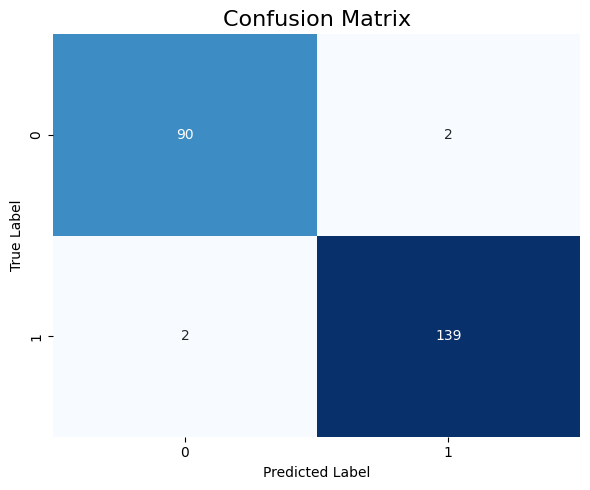

In [ ]:
# ✅ Decision Tree (DT)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Decision Tree model
model = DecisionTreeClassifier(
    criterion="gini",      # or "entropy"
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Test Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix", fontsize=16)
plt.tight_layout()
plt.show()


# Ensemble


========== ENSEMBLE (VOTING) K-FOLD CV START ==========


================ FOLD 1 ================

Fold 1 Accuracy: 98.29%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        93
           1       0.99      0.99      0.99       141

    accuracy                           0.98       234
   macro avg       0.98      0.98      0.98       234
weighted avg       0.98      0.98      0.98       234


================ FOLD 2 ================

Fold 2 Accuracy: 98.71%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98        93
           1       0.99      0.99      0.99       140

    accuracy                           0.99       233
   macro avg       0.99      0.99      0.99       233
weighted avg       0.99      0.99      0.99       233


================ FOLD 3 ================

Fold 3 Accuracy: 99.14%

Classification Report:
              p

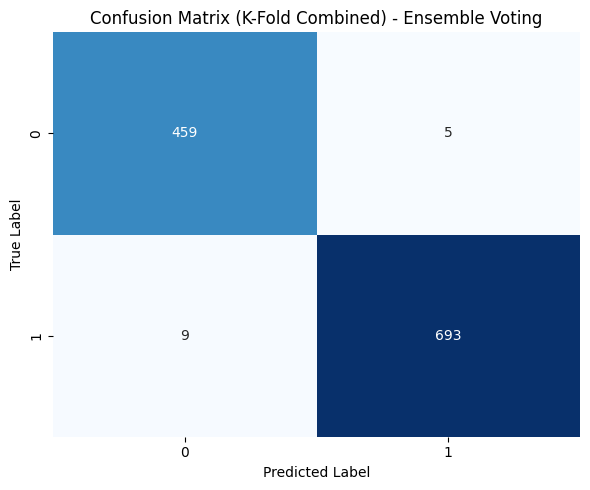


ROC AUC Score: 0.9991


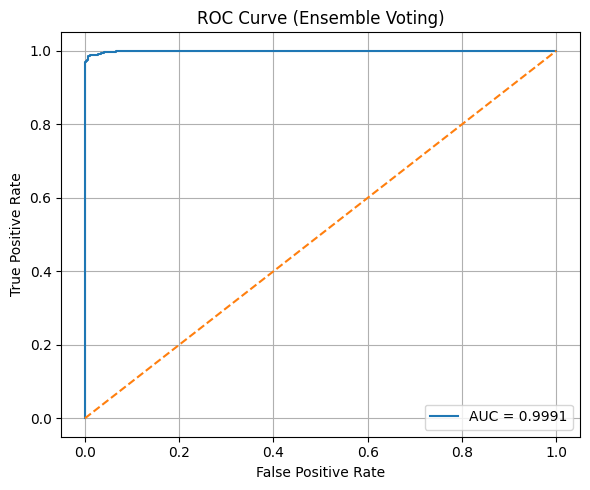


========== K-FOLD CV COMPLETED ==========



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.ensemble import VotingClassifier

# ==============================
# Build Base Models
# ==============================

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5, weights="distance", p=2))
])

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)

n_classes = len(np.unique(y))

if n_classes == 2:
    xgb_model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
else:
    xgb_model = XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

# ==============================
# Ensemble (Soft Voting)
# ==============================

ensemble_model = VotingClassifier(
    estimators=[
        ("svm", svm_model),
        ("knn", knn_model),
        ("dt", dt_model),
        ("xgb", xgb_model),
    ],
    voting="soft",
    n_jobs=-1,
    weights=[1, 1, 1, 2]
)

# ==============================
# K-Fold Cross Validation
# ==============================

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []
all_y_true = []
all_y_pred = []
all_y_prob = []

print("\n========== ENSEMBLE (VOTING) K-FOLD CV START ==========\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\n================ FOLD {fold} ================")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    ensemble_model.fit(X_train, y_train)

    y_pred = ensemble_model.predict(X_test)
    y_prob = ensemble_model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

    print(f"\nFold {fold} Accuracy: {acc * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# ==============================
# Overall Results
# ==============================

print("\n========== OVERALL RESULTS (ALL FOLDS) ==========\n")

print("Fold-wise Accuracy:")
for i, acc in enumerate(fold_accuracies, start=1):
    print(f"Fold {i}: {acc * 100:.2f}%")

print(f"\nMean Accuracy: {np.mean(fold_accuracies) * 100:.2f}%")
print(f"Std Deviation: {np.std(fold_accuracies) * 100:.2f}%")

print("\nOverall Classification Report:")
print(classification_report(all_y_true, all_y_pred))

# ==============================
# Confusion Matrix
# ==============================

cm = confusion_matrix(all_y_true, all_y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (K-Fold Combined) - Ensemble Voting")
plt.tight_layout()
plt.show()

# ==============================
# ROC Curve (Binary only)
# ==============================

if n_classes == 2:
    y_prob_bin = np.array(all_y_prob)[:, 1]

    fpr, tpr, _ = roc_curve(all_y_true, y_prob_bin)
    roc_auc = auc(fpr, tpr)

    print(f"\nROC AUC Score: {roc_auc:.4f}")

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Ensemble Voting)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\n========== K-FOLD CV COMPLETED ==========\n")


# Explainable AI with SHAP

This section explains **which features influence the model most** (global explanation) and **why a specific prediction was made** (local explanation).


In [ ]:
# Install SHAP if needed (Colab/Jupyter)
try:
    import shap
except ImportError:
    !pip -q install shap
    import shap

import numpy as np
shap.initjs()

# For speed, explain a sample of the test set
X_explain = X_test.copy()
if X_explain.shape[0] > 1000:
    X_explain = X_explain.sample(1000, random_state=42)


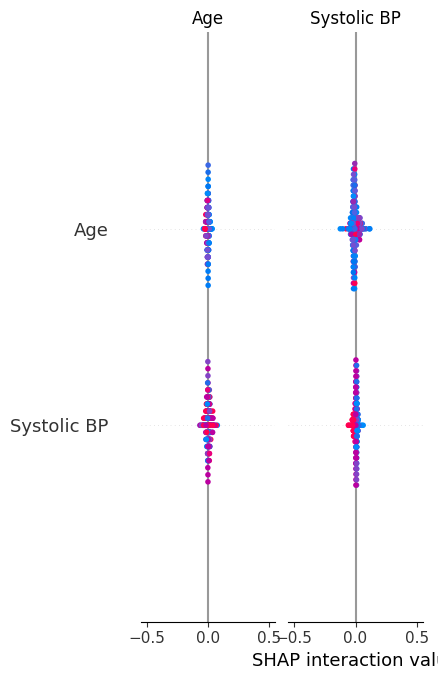

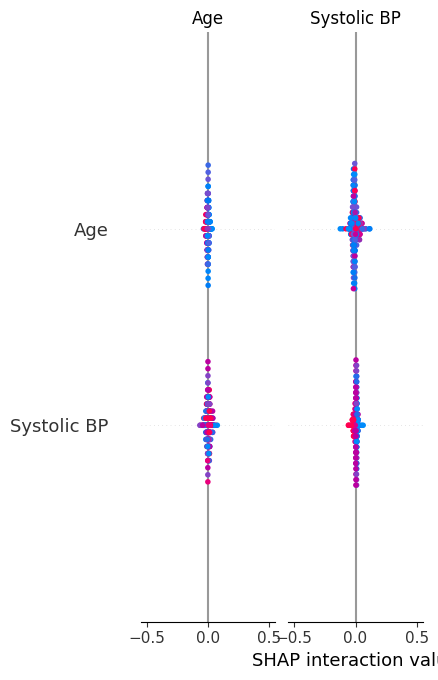

In [ ]:

explainer = shap.TreeExplainer(model)


shap_values = explainer.shap_values(X_explain)


if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_vals_for_plot = shap_values[1]
else:
    shap_vals_for_plot = shap_values


shap.summary_plot(shap_vals_for_plot, X_explain, show=True)


shap.summary_plot(shap_vals_for_plot, X_explain, plot_type='bar', show=True)


Predicted class: 1
Predicted probabilities: [0. 1.]


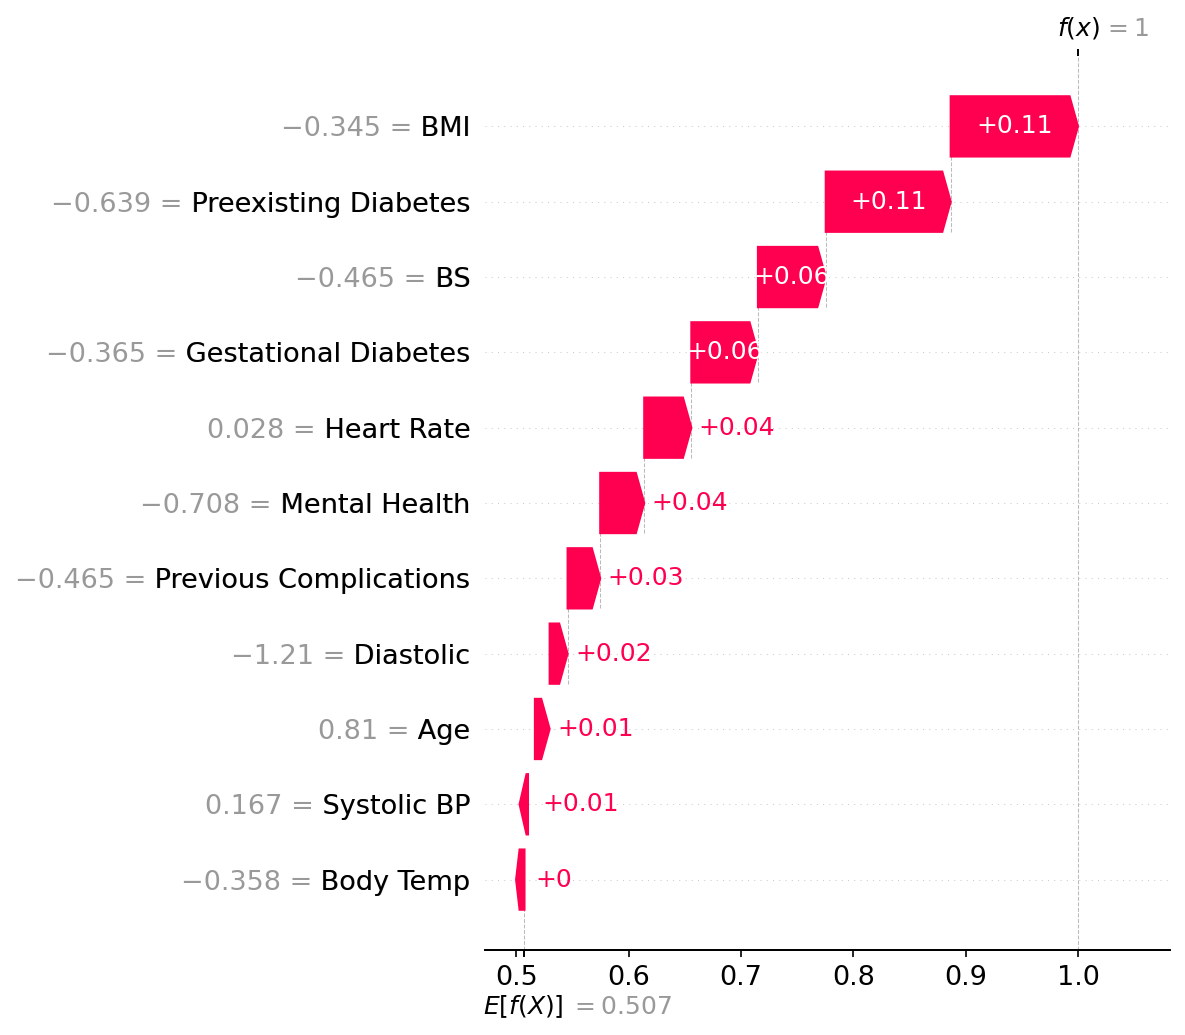

In [ ]:


import numpy as np
import shap
import matplotlib.pyplot as plt
import textwrap


shap.initjs()


row_id = 0
x_row = X_test.iloc[row_id:row_id+1]

pred_class = model.predict(x_row)[0]
pred_proba = model.predict_proba(x_row)[0]
print("Predicted class:", pred_class)
print("Predicted probabilities:", pred_proba)


sv_row = explainer.shap_values(x_row)


if isinstance(sv_row, list) and len(sv_row) >= 2:
    # list of arrays per class: [(1,nf), (1,nf), ...]
    sv = sv_row[pred_class][0]  # (num_features,)
    base = explainer.expected_value[pred_class] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
elif isinstance(sv_row, np.ndarray) and sv_row.ndim == 3:
    # (1, num_features, num_classes)
    sv = sv_row[0, :, pred_class]
    base = explainer.expected_value[pred_class] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    # fallback
    sv = sv_row[0] if hasattr(sv_row, "ndim") and sv_row.ndim > 1 else sv_row
    base = explainer.expected_value

feature_names = list(X_test.columns)


try:
    exp = shap.Explanation(
        values=sv,
        base_values=base,
        data=x_row.iloc[0].values,
        feature_names=feature_names
    )

    plt.figure(figsize=(18, 6))
    shap.plots.waterfall(exp, max_display=20, show=False)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Waterfall plot not available in this SHAP version:", e)


TOP_K = 8

idx = np.argsort(np.abs(sv))[::-1][:TOP_K]
sv_top = sv[idx]
x_top = x_row.iloc[:, idx]
names_top = [feature_names[i] for i in idx]

# optional: wrap long feature names for readability
names_top = [textwrap.fill(n, width=18) for n in names_top]

# Interactive force plot (Colab-friendly)
shap.force_plot(
    base,
    sv_top,
    x_top,
    feature_names=names_top
)
